In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Load data & compute treatment effects

In [3]:
data = slk.datasets.replogle()

In [4]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
print("Pathways:", len(pathways))

Perturbations: 682
Pathways: 8


In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect'
)

100%|██████████| 681/681 [00:08<00:00, 77.36it/s]


## Train cVAE

Architecture:
- **Encoder** `q(U | x)` — background latent from expression only, no label
- **Shift** `z = U + A[p]` — linear shift in latent space; `A[NTC] = 0` (frozen)
- **Decoder** `p(x | z)` — perturbation-agnostic
- **Counterfactuals** via base class: abduct `U_i` from NTC, decode `U_i + A[p]`

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(
    data,
    model='cvae',
    validate_every=50,
    batch_size=4096,
    shuffle=True,
    num_workers=9,
    device=device,
)

cVAE: 100%|██████████| 200/200 [03:08<00:00,  1.06it/s, ATE=0.3562, KLw=1.00, R2=0.9647, loss=211488262.6207]


In [7]:
model = results['model']

## Save & load

In [8]:
slk.tl.save_results(results, '../results/cvae_model.pth')

In [9]:
model = slk.tl.load_results('../results/cvae_model.pth')

## Evaluate

`z` stores the perturbed latent `z = U + A[p]` per cell.  
`rho_corr` is the Pearson correlation of learned shift vectors `A[p]` (the model's perturbation similarity structure).

In [10]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")
data.uns['results'].keys()

dict_keys(['z_corr', 'perts', 'rho_corr', 'rho_perts', 'rho_embed'])

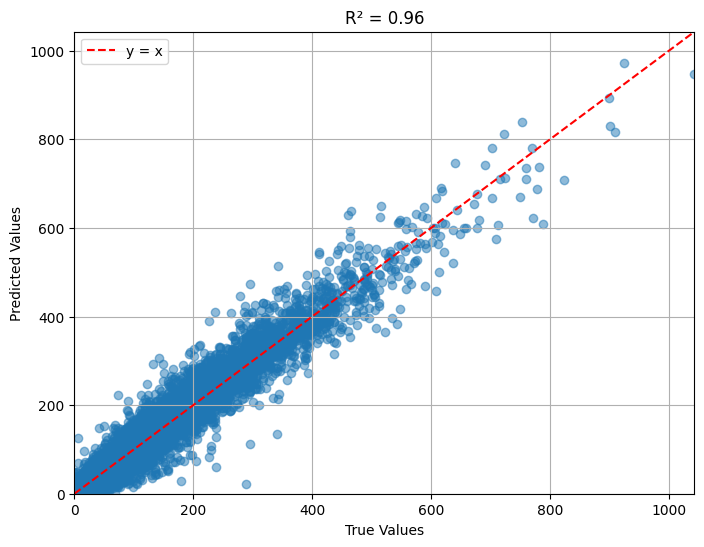

In [11]:
slk.pl.plot_r2(data)

## UMAP of perturbed latent z

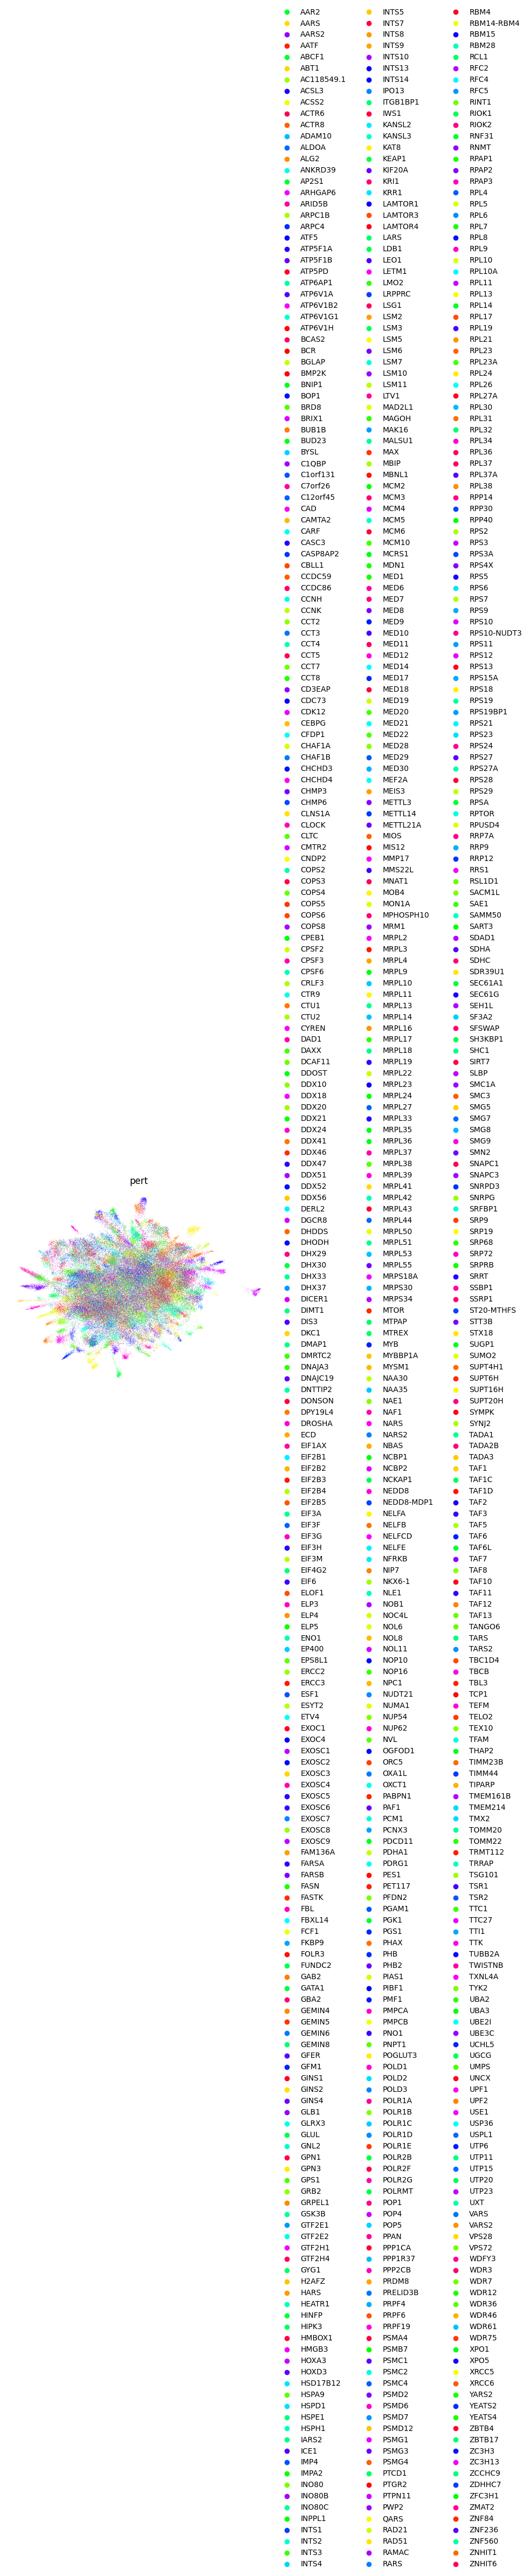

In [12]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

## Perturbation embedding correlation (rho_corr)

`rho_corr` is computed from learned shift vectors `A[p]` — the cVAE's perturbation similarity.

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


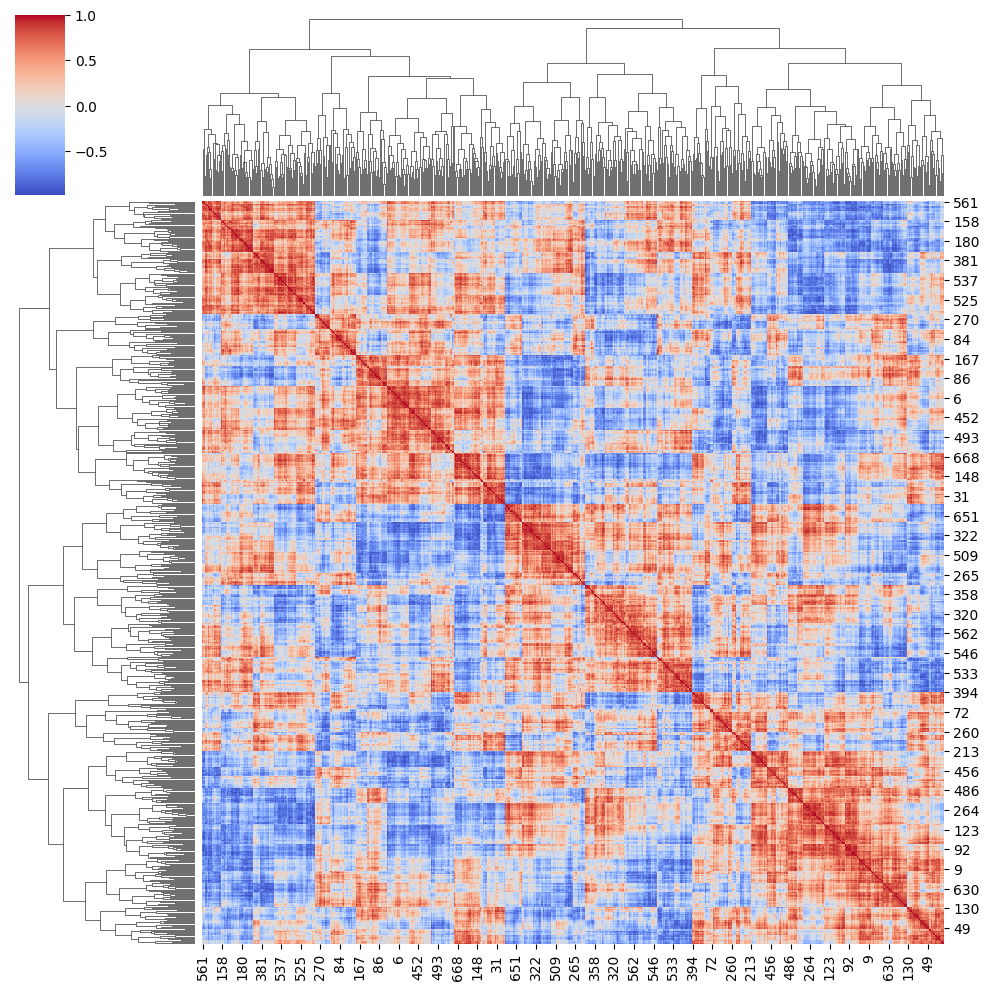

In [15]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

Uses base class `predict_counterfactual_effects`: abducts `U_i` from NTC cells,
K-means in U-space, then decodes `U_k + A[p]` vs `U_k` (baseline = decode(U), since A[NTC]=0).

In [19]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print("Pearson r (predicted vs observed ATE):", ate['corr'])

Pearson r (predicted vs observed ATE): 0.39807629585266113


In [33]:
z_corr = data.uns['results'].get('z_corr')
rho_corr = data.uns['results'].get('rho_corr')

from scipy.stats import pearsonr, spearmanr

pearson = pearsonr(z_corr.flatten(), rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())

print(f"Spearman ρ = {spearman[0]:.3f}  (p = {spearman[1]:.1e})")
print(f" Pearson  r = {pearson[0]:.3f}  (p = {pearson[1]:.1e})") 

Spearman ρ = 0.899  (p = 0.0e+00)
 Pearson  r = 0.899  (p = 0.0e+00)


## Replogle pathway clustering

Subset `rho_corr` (correlation of `A[p]` vectors) to pathway genes, then cluster.

In [ ]:
rho_perts = data.uns['results']['rho_perts']
print(f"rho_corr shape: {rho_corr.shape}, perts: {len(rho_perts)}")

rho_corr shape: (681, 681), perts: 681


In [34]:
C = rho_corr
C = data.uns['results']['z_corr']

In [35]:
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

rho_perts_list = list(rho_perts)
gene_ids = [rho_perts_list.index(g) for g in all_genes if g in rho_perts_list]
pathway_genes_found = [g for g in all_genes if g in rho_perts_list]

print(f"Found {len(pathway_genes_found)} / {len(all_genes)} pathway genes in rho_perts")
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

Found 335 / 335 pathway genes in rho_perts


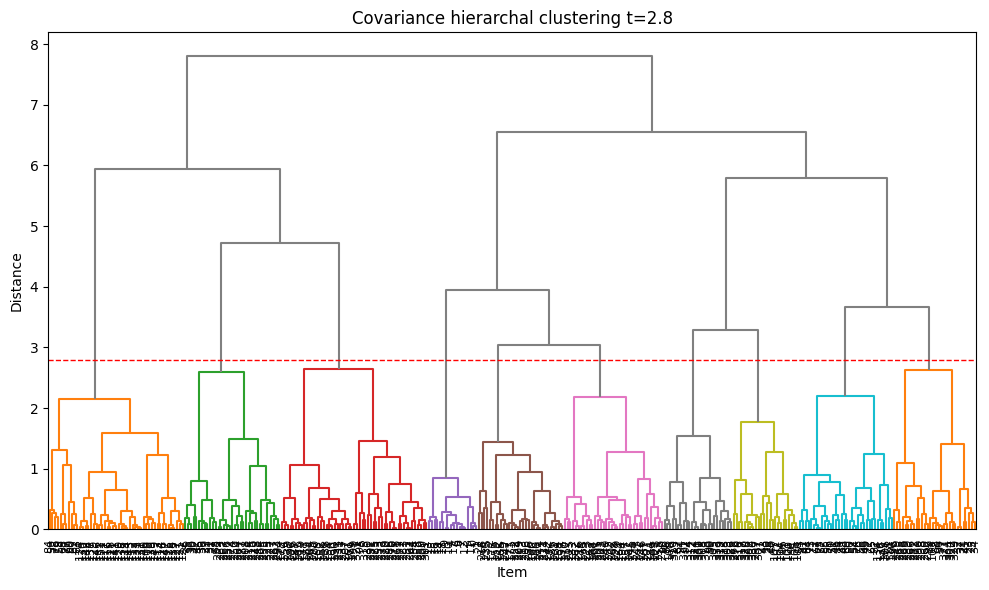

In [36]:
groups = slk.tl.cluster_rho(data, t=2.8, rho_corr=cov_subset, show=True)

In [37]:
named_groups = slk.tl.group2name(groups, pathway_genes_found)
named_groups

,group
ZC3H3,4
ZFC3H1,4
CAMTA2,5
DHX29,4
DIS3,4
...,...
SNRPG,8
TIPARP,7
TTC27,7
TXNL4A,7


## Clustering metrics vs ground-truth pathways

In [38]:
from collections import Counter

gene_counts  = Counter(pathway_genes_found)
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]
if shared_genes:
    print(f"⚠️  {len(shared_genes)} genes shared across pathways: {shared_genes[:10]}")
else:
    print("✅ Each gene appears in exactly one pathway.")

perts_df = pd.DataFrame(groups, index=pathway_genes_found, columns=['cluster'])

gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes
    if gene in rho_perts_list
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient='index', columns=['cluster'])

perts_df   = perts_df.drop(shared_genes, errors='ignore')
pathway_df = pathway_df.drop(shared_genes, errors='ignore')

print(f"perts_df: {perts_df.shape}  |  pathway_df: {pathway_df.shape}")

✅ Each gene appears in exactly one pathway.
perts_df: (335, 1)  |  pathway_df: (335, 1)


In [39]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']

perts_aligned = perts_df.loc[pathway_df.index].copy()
perts_aligned['gene'] = perts_aligned.index.copy()

In [40]:
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure, silhouette_score,
    precision_score, recall_score, f1_score,
)
from scipy.optimize import linear_sum_assignment

def align_and_summarize(
    clusters_df, pathways_df,
    gene_col='gene', cluster_col='cluster', pathway_col='pathway',
    min_pathway_size=1, gene_embeddings=None,
):
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how='inner', validate='one_to_one'
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}
    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped    = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match  = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average='macro', zero_division=0)
    recall    = recall_score(y_true, mapped, average='macro', zero_division=0)
    f1        = f1_score(y_true, mapped, average='macro', zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, comp, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    sil = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        sil = silhouette_score(emb, mapped, metric='euclidean')

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority    = g[pathway_col].mode().iat[0]
        purity      = (g[pathway_col] == majority).mean()
        pathway_tot = (df[pathway_col] == majority).sum()
        recall_cl   = (g[pathway_col] == majority).sum() / pathway_tot
        purity_rows.append({'cluster': str(cl), 'size': len(g),
                            'mapped_pathway': mapping.get(str(cl)),
                            'purity': purity, 'recall': recall_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values('cluster').set_index('cluster')

    df['mapped_pathway'] = mapped
    df['is_match']       = is_match

    return {
        'merged': df[[gene_col, cluster_col, pathway_col, 'mapped_pathway', 'is_match']].rename(
            columns={gene_col: 'gene', cluster_col: 'cluster', pathway_col: 'pathway'}),
        'mapping': mapping, 'accuracy': accuracy,
        'precision': precision, 'recall': recall, 'f1': f1,
        'ari': ari, 'ami': ami,
        'homogeneity': hom, 'completeness': comp, 'v_measure': vmeas,
        'silhouette': sil,
        'purity_df': purity_df,
        'contingency': contingency_df,
    }

In [41]:
# Gene embeddings for silhouette: A[p] shift vectors from rho_embed
rho_embed = data.uns['results']['rho_embed']   # (P_non_ntc, latent_dim)
gene_embeddings = pd.DataFrame(rho_embed, index=list(rho_perts))
gene_embeddings = gene_embeddings.loc[
    gene_embeddings.index.intersection(perts_aligned.index)
]

cluster_results = align_and_summarize(
    clusters_df=perts_aligned,
    pathways_df=pathway_df,
    gene_col='gene',
    cluster_col='cluster',
    pathway_col='pathway',
    min_pathway_size=1,
    gene_embeddings=gene_embeddings,
)

print("Best cluster→pathway mapping:")
for cl, pw in cluster_results['mapping'].items():
    print(f"  {cl} → {pw}")

print(f"\nAccuracy:    {cluster_results['accuracy']:.3f}")
print(f"Precision:   {cluster_results['precision']:.3f}  Recall: {cluster_results['recall']:.3f}  F1: {cluster_results['f1']:.3f}")
print(f"ARI: {cluster_results['ari']:.3f}  AMI: {cluster_results['ami']:.3f}")
print(f"Homogeneity: {cluster_results['homogeneity']:.3f}  Completeness: {cluster_results['completeness']:.3f}  V-measure: {cluster_results['v_measure']:.3f}")
if cluster_results['silhouette'] is not None:
    print(f"Silhouette:  {cluster_results['silhouette']:.3f}")
print("\nPer-cluster purity:")
print(cluster_results['purity_df'])

Best cluster→pathway mapping:
  4 → EXOSOME
  2 → MEDIATOR_COMPLEX
  9 → MT_PROTEIN_TRANSLOCATION
  8 → NUCLEOTIDE_EXCISION_REPAIR
  1 → S39_RIBOSOMAL_UNIT
  6 → S40_RIBOSOMAL_UNIT
  3 → S60_RIBOSOMAL_UNIT
  7 → SPLICEOSOME
  10 → S60_RIBOSOMAL_UNIT
  5 → S40_RIBOSOMAL_UNIT

Accuracy:    0.660
Precision:   0.674  Recall: 0.647  F1: 0.650
ARI: 0.381  AMI: 0.567
Homogeneity: 0.635  Completeness: 0.548  V-measure: 0.589
Silhouette:  0.008

Per-cluster purity:
         size              mapped_pathway    purity    recall
cluster                                                      
1          49          S39_RIBOSOMAL_UNIT  0.775510  0.883721
10         30          S60_RIBOSOMAL_UNIT  0.433333  0.245283
2          35            MEDIATOR_COMPLEX  0.457143  0.301887
3          53          S60_RIBOSOMAL_UNIT  0.509434  0.278351
4          18                     EXOSOME  1.000000  0.900000
5          31          S40_RIBOSOMAL_UNIT  0.903226  0.288660
6          36          S40_RIBOSOMAL_UNIT  

## UMAP coloured by true pathway vs predicted cluster

/var/tmp/ipykernel_2439182/1426620886.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_cats))


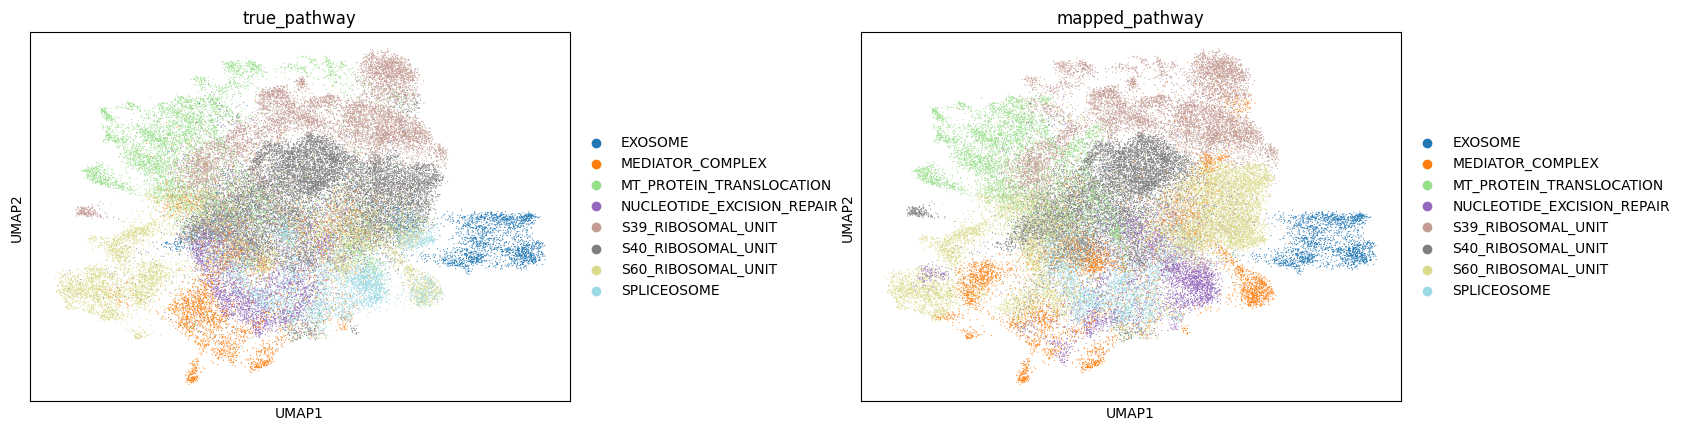

In [42]:
results_df = cluster_results['merged']
clustered_genes = results_df['gene'].unique()

z_sub = sub[sub.obs['pert'].isin(clustered_genes)].copy()
sc.pp.neighbors(z_sub, use_rep='z')
sc.tl.umap(z_sub)

from matplotlib.colors import to_hex

gene_to_true   = dict(zip(results_df['gene'], results_df['pathway']))
gene_to_mapped = dict(zip(results_df['gene'], results_df['mapped_pathway']))

z_sub.obs['true_pathway']   = z_sub.obs['pert'].map(gene_to_true)
z_sub.obs['mapped_pathway'] = z_sub.obs['pert'].map(gene_to_mapped)
z_sub = z_sub[z_sub.obs['mapped_pathway'].notna() & (z_sub.obs['mapped_pathway'] != 'NA')].copy()

all_cats  = pd.Index(np.unique(
    list(z_sub.obs['true_pathway'].dropna().unique()) +
    list(z_sub.obs['mapped_pathway'].dropna().unique())
))
cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

cmap = plt.cm.get_cmap('tab20', len(all_cats))
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}
z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in all_cats]
z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in all_cats]

sc.pl.umap(z_sub, color=['true_pathway', 'mapped_pathway'], wspace=0.4)